# Adversarial Score Functions for Conformal Prediction

In [1]:
import secml
import torch
from torch import nn
from torch import optim
import foolbox
import numpy as np
import random
import matplotlib.pyplot as plt
from secml.array import CArray


## Load MNIST

In [2]:
from secml.data.loader import CDataLoaderMNIST

# MNIST dataset will be downloaded and cached if needed
loader = CDataLoaderMNIST()

In [3]:
random_state = 999

n_tr = 1000  # Number of training set samples
n_val = 500  # Number of validation set samples
n_ts = 5000  # Number of test set samples
n_cl = 5000 # Number of calibration set samples

digits = (0, 1, 2, 3, 4, 5, 6, 7, 8, 9)

learning_set = loader.load('training', digits=digits, num_samples=n_tr + n_val + n_cl + n_ts)
#learning_set = loader.load('training', digits=digits, num_samples=n_tr + n_val + n_cl)
#test_set = loader.load('testing', digits=digits, num_samples=n_ts)

# Split the learning set into training, validation, and calibration sets
training_set = learning_set[:n_tr, :]  
validation_set = learning_set[n_tr:n_tr + n_val, :]  
calibration_set = learning_set[n_tr + n_val:, :]  
calibration_set = learning_set[n_tr + n_val:n_tr + n_val + n_cl, :]  
test_set = learning_set[n_tr + n_val + n_cl:, :]  

# Shuffle data

rng = np.random.default_rng(seed=random_state)  # Random generator with seed for reproducibility
shuffled_indices_tr = rng.permutation(n_tr).tolist()  # Shuffle along the first axis (rows)
# Apply the shuffled indices to test_set.X and test_set.Y
training_set.X = training_set[shuffled_indices_tr, :].X  # Shuffle rows of the feature matrix
training_set.Y = training_set[shuffled_indices_tr,:].Y    # Shuffle corresponding labels

rng = np.random.default_rng(seed=random_state)  # Random generator with seed for reproducibility
shuffled_indices_val = rng.permutation(n_val).tolist()  # Shuffle along the first axis (rows)
# Apply the shuffled indices to test_set.X and test_set.Y
validation_set.X = validation_set[shuffled_indices_val, :].X  # Shuffle rows of the feature matrix
validation_set.Y = validation_set[shuffled_indices_val,:].Y    # Shuffle corresponding labels

rng = np.random.default_rng(seed=random_state)  # Random generator with seed for reproducibility
shuffled_indices_cl = rng.permutation(n_cl).tolist()  # Shuffle along the first axis (rows)
# Apply the shuffled indices to test_set.X and test_set.Y
calibration_set.X = calibration_set[shuffled_indices_cl, :].X  # Shuffle rows of the feature matrix
calibration_set.Y = calibration_set[shuffled_indices_cl,:].Y    # Shuffle corresponding labelsù

rng = np.random.default_rng(seed=random_state)  # Random generator with seed for reproducibility
shuffled_indices_ts = rng.permutation(n_ts).tolist()  # Shuffle along the first axis (rows)
# Apply the shuffled indices to test_set.X and test_set.Y
test_set.X = test_set[shuffled_indices_ts, :].X  # Shuffle rows of the feature matrix
test_set.Y = test_set[shuffled_indices_ts,:].Y    # Shuffle corresponding labels

# Normalize the features in `[0, 1]`
training_set.X /= 255
validation_set.X /= 255
test_set.X /= 255
calibration_set.X /= 255

In [4]:
print(test_set.Y)
print(training_set)

CArray([4 1 9 ... 7 8 2])
CDataset{'X': CArray(1000, 784)(dense: [[0. 0. 0. ... 0. 0. 0.] [0. 0. 0. ... 0. 0. 0.] [0. 0. 0. ... 0. 0. 0.] ... [0. 0. 0. ... 0. 0. 0.] [0. 0. 0. ... 0. 0. 0.] [0. 0. 0. ... 0. 0. 0.]]), 'Y': CArray(1000,)(dense: [8 2 6 ... 1 2 2]), 'header': CDatasetHeader{'num_samples': None, 'img_w': 28, 'img_h': 28, 'y_original': (0, 1, 2, 3, 4, 5, 6, 7, 8, 9)}}


## SVM


In [5]:
# Creation of the multiclass classifier
from secml.ml.classifiers import CClassifierSVM
from secml.ml.kernels import CKernelRBF

clf = CClassifierSVM(kernel=CKernelRBF())

#svm = CClassifierSVM()

# Parameters for the Cross-Validation procedure
xval_params = {'C': [1], 'kernel.gamma': [.05, 1]}
#xval_params = {'C': [0.1, 1, 10]}

# Let's create a 3-Fold data splitter
from secml.data.splitter import CDataSplitterKFold
xval_splitter = CDataSplitterKFold(num_folds=3, random_state=random_state)

# Metric to use for training and performance evaluation
from secml.ml.peval.metrics import CMetricAccuracy
metric = CMetricAccuracy()

# Select and set the best training parameters for the classifier
print("Estimating the best training parameters...")
best_params = clf.estimate_parameters(
    dataset=training_set, 
    parameters=xval_params, 
    splitter=xval_splitter, 
    metric=metric, 
    perf_evaluator='xval'
)

print("The best training parameters are: ", 
      [(k, best_params[k]) for k in sorted(best_params)])

# We can now fit the classifier
clf.fit(training_set.X, training_set.Y)

# Compute predictions on a test set
y_pred = clf.predict(test_set.X)

# Evaluate the accuracy of the classifier
acc = metric.performance_score(y_true=test_set.Y, y_pred=y_pred)

print("Accuracy on test set: {:.2%}".format(acc)),

Estimating the best training parameters...
The best training parameters are:  [('C', 1), ('kernel.gamma', 0.05)]
Accuracy on test set: 89.20%


(None,)

In [6]:
# Input to analyze
random_number = random.randint(1, n_ts)

x_sample = test_set[random_number, :].X  # Or any sample you want to analyze

# Get scores for all classes
scores = clf.decision_function(x_sample)

print("Scores for each class: ", scores)
print("Predicted class (clf.predict): ", scores.argmax())
print("Predicted class (argmax(decison_function)): ", clf.predict(x_sample))

Scores for each class:  CArray([[ 0.221545 -1.012271 -0.867697 -0.973375 -0.949006 -0.997542 -0.875371
  -0.910529 -0.948187 -0.906186]])
Predicted class (clf.predict):  0
Predicted class (argmax(decison_function)):  CArray([0])


## Computing the attacked samples

In [7]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [8]:
from secml.adv.attacks.evasion import CFoolboxPGDL2

In [9]:
epsilon = 2.0

In [ ]:
from joblib import Parallel, delayed
from tqdm import tqdm

# Define the optimized PGD function
def PGD_optimized(x, y, clf, y_target=None, epsilon=epsilon, step_size=0.1, steps=100, lb=0.0, ub=1.0):
    # Define the PGD attack only once per parameter set
    pgd_attack = CFoolboxPGDL2(clf, y_target, lb=lb, ub=ub, epsilons=epsilon, abs_stepsize=step_size, steps=steps, random_start=False)
    
    # Apply the attack
    _, _, adv_ds_pgd, _ = pgd_attack.run(x, y)
    return adv_ds_pgd.X

# Parallelized loop for attacking the dataset
def attack_dataset(dataset, desc, clf, epsilon, step_size=0.1, steps=100, lb=0.0, ub=1.0):
    def attack_sample(i):
        x, y = dataset[i, :].X, dataset[i, :].Y  # Extract sample
        return PGD_optimized(x, y, clf, epsilon=epsilon, step_size=step_size, steps=steps, lb=lb, ub=ub)
    
    # Use joblib for parallel processing
    attacked_data = Parallel(n_jobs=-1)(
        delayed(attack_sample)(i) for i in tqdm(range(dataset.X.shape[0]), desc=desc, unit="sample")
    )
    return attacked_data

# Attack calibration and test sets
calibration_attacked = attack_dataset(calibration_set, "Attacking the Calibration set", clf, epsilon=epsilon)
test_attacked = attack_dataset(test_set, "Attacking the Test set", clf, epsilon=epsilon)


Attacking the Calibration set:  99%|█████████▉| 4968/5000 [03:18<00:01, 26.44sample/s]

### Attack success plot

In [40]:
# Error of the classifier
test_subset = test_set[:50,:]

y_test_pred = clf.predict(test_subset.X)
svm_error = 1 - np.sum(test_subset.Y.tondarray() == y_test_pred.tondarray()) / len(test_subset.Y.tondarray())

# Epsilon values
Epsilon = np.linspace(0, 5, 50)  # Generate 50 values between 0.01 and 1

# Array to store the percentage of successfully attacked points
success_rates = []

# Iterate over each epsilon value
for eps in tqdm(Epsilon, desc="Evaluating success rates"):
    # Perform the attack on the test set
    attacked_test = attack_dataset(test_subset, f"Attacking with epsilon={eps}", clf, epsilon=eps)
    attacked_test_array = np.vstack([sample.tondarray() for sample in attacked_test])
    attacked_test = CArray(attacked_test_array)

    # Predict with the attacked data
    y_pred_adv = clf.predict(attacked_test)
    
    # Check how many points were misclassified
    success_count = np.sum(y_pred_adv.tondarray() != test_subset.Y.tondarray())
    total_points = len(test_subset.Y.tondarray())
    
    # Calculate the success rate (percentage)
    success_rate = (success_count / total_points) * 100
    success_rates.append(success_rate)
    
# Plot the results
plt.figure(figsize=(8, 5))
plt.plot(Epsilon, success_rates, marker='o', linestyle='-', color='b', label='Attack Success Rate')

# Add a horizontal line for the SVM error
plt.axhline(y=svm_error * 100, color='red', linestyle='--', label='Classifier Error')

# Add labels, title, and legend
plt.xlabel('Epsilon')
plt.ylabel('Attack Success Rate (%)')
plt.title('Attack Success Rate vs Epsilon')
plt.grid(True)
plt.legend()

# Show the plot
plt.show()

Attacking with epsilon=0.0: 100%|██████████| 50/50 [00:03<00:00, 14.62sample/s]Exception ignored in: <function _xla_gc_callback at 0x7f584508f940>
Traceback (most recent call last):
  File "/usr/local/lib/python3.8/dist-packages/jax/_src/lib/__init__.py", line 103, in _xla_gc_callback
    def _xla_gc_callback(*args):
KeyboardInterrupt: 
Exception ignored in: <function _xla_gc_callback at 0x7fdac8cd1940>
Traceback (most recent call last):
  File "/usr/local/lib/python3.8/dist-packages/jax/_src/lib/__init__.py", line 103, in _xla_gc_callback
    def _xla_gc_callback(*args):
KeyboardInterrupt: 

Exception ignored in: <function _xla_gc_callback at 0x7f8b4858c940>
Traceback (most recent call last):
  File "/usr/local/lib/python3.8/dist-packages/jax/_src/lib/__init__.py", line 103, in _xla_gc_callback
    def _xla_gc_callback(*args):
KeyboardInterrupt: 
Evaluating success rates:   0%|          | 0/50 [00:03<?, ?it/s]


KeyboardInterrupt: 

## Conformal Prediction

In [12]:
def s(x, y, method = 'lac'):
    
    if method == 'lac':
    
        output = clf.decision_function(x).tondarray()[0]
        return 1 - output[int(y.tondarray()[0])]

In [13]:
random_number = random.randint(1, n_cl)
print(random_number)
x0, y0 = calibration_set[random_number, :].X, calibration_set[random_number, :].Y  # Initial sample
x0_tilde = calibration_attacked[random_number]
print("Original Score:", s(x0, y0))
print("Attack-informed Score:", s(x0_tilde, y0))


124
Original Score: 1.367593801601686
Attack-informed Score: 2.153699743375296


## Compute scores

### Calibration

In [28]:
cl_classic_scores = []  # To store the scores for each data point
cl_attacked_scores = []

for i in range(n_cl):
    
    x = calibration_set[i,:].X
    y = calibration_set[i,:].Y
    
    x_tilde = calibration_attacked[i]
    
    score = s(x,y)
    score_a = s(x_tilde,y)
    
    cl_classic_scores.append(score)
    cl_attacked_scores.append(score_a)
    
cl_classic_scores = np.array(cl_classic_scores) 
cl_attacked_scores = np.array(cl_attacked_scores) 

### Test


In [29]:
ts_classic_scores = []  # To store the scores for each data point
ts_attacked_scores = []

for i in range(n_ts):
    
    x = test_set[i,:].X
    y = test_set[i,:].Y
    
    x_tilde = test_attacked[i]
    
    score = s(x,y)
    score_a = s(x_tilde,y)
    
    ts_classic_scores.append(score)
    ts_attacked_scores.append(score_a)
    
ts_classic_scores = np.array(ts_classic_scores) 
ts_attacked_scores = np.array(ts_attacked_scores) 

### Quantiles

In [16]:
import numpy as np

In [55]:
alpha = 0.1
method = 'lac'

# Compute qhat
q_level = np.ceil((n_cl + 1) * (1 - alpha)) / n_cl

qhat = np.quantile(cl_classic_scores, q_level, method='higher')
qhat_A = np.quantile(cl_attacked_scores, q_level, method='higher')

print('Classic quantile:', qhat)
print('Attacked quantile:', qhat_A)

Classic quantile: 1.5745466589876047
Attacked quantile: 2.6491554533826847


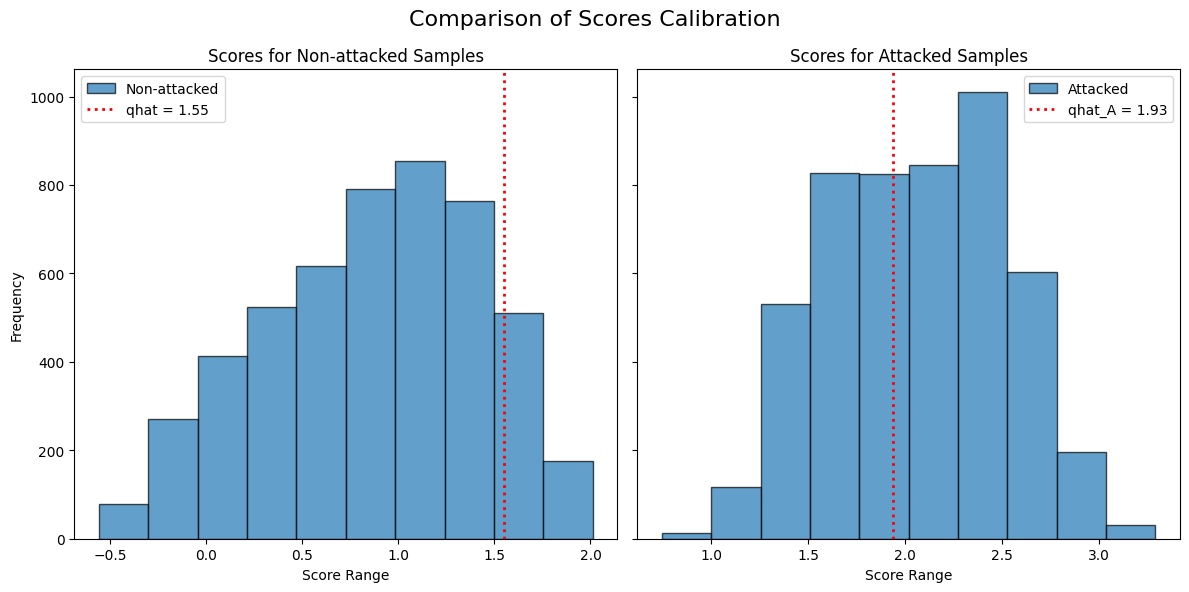

In [30]:
# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# Histogram for non-attacked scores
axs[0].hist(cl_classic_scores, bins=10, edgecolor='black', alpha=0.7, label='Non-attacked')
axs[0].axvline(x=qhat, color='red', linestyle='dotted', linewidth=2, label=f'qhat = {qhat:.2f}')
axs[0].set_title('Scores for Non-attacked Samples')
axs[0].set_xlabel('Score Range')
axs[0].set_ylabel('Frequency')
axs[0].legend()

# Histogram for attacked scores
axs[1].hist(cl_attacked_scores, bins=10, edgecolor='black', alpha=0.7, label='Attacked')
axs[1].axvline(x=qhat_A, color='red', linestyle='dotted', linewidth=2, label=f'qhat_A = {qhat_A:.2f}')
axs[1].set_title('Scores for Attacked Samples')
axs[1].set_xlabel('Score Range')
axs[1].legend()

# Add an overall title and adjust layout
fig.suptitle(f'Comparison of Scores Calibration', fontsize=16)
plt.tight_layout()
plt.show()

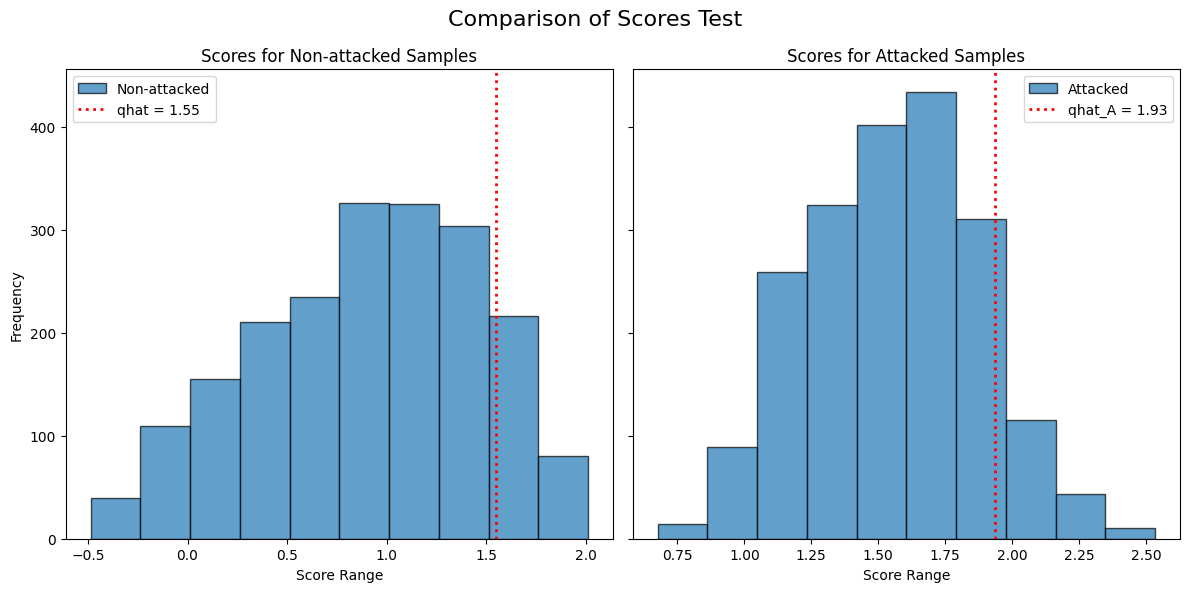

In [27]:
# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# Histogram for non-attacked scores
axs[0].hist(ts_classic_scores, bins=10, edgecolor='black', alpha=0.7, label='Non-attacked')
axs[0].axvline(x=qhat, color='red', linestyle='dotted', linewidth=2, label=f'qhat = {qhat:.2f}')
axs[0].set_title('Scores for Non-attacked Samples')
axs[0].set_xlabel('Score Range')
axs[0].set_ylabel('Frequency')
axs[0].legend()

# Histogram for attacked scores
axs[1].hist(ts_attacked_scores, bins=10, edgecolor='black', alpha=0.7, label='Attacked')
axs[1].axvline(x=qhat_A, color='red', linestyle='dotted', linewidth=2, label=f'qhat_A = {qhat_A:.2f}')
axs[1].set_title('Scores for Attacked Samples')
axs[1].set_xlabel('Score Range')
axs[1].legend()

# Add an overall title and adjust layout
fig.suptitle(f'Comparison of Scores Test', fontsize=16)
plt.tight_layout()
plt.show()

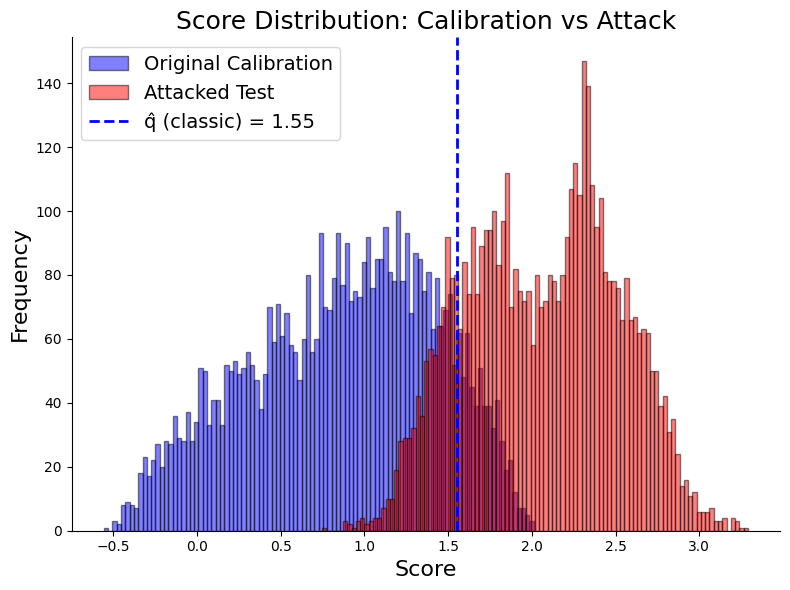

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# Plot histogram for classic calibration set
plt.hist(cl_classic_scores, bins=100, edgecolor='black', alpha=0.5, label='Original Calibration', color='blue')

# Plot histogram for attacked test set
plt.hist(cl_attacked_scores, bins=100, edgecolor='black', alpha=0.5, label='Attacked Test', color='red')

# Plot only the classic quantile
plt.axvline(x=qhat, color='blue', linestyle='dashed', linewidth=2, label=f'q̂ (classic) = {qhat:.2f}')

# Titles and labels with increased font sizes
plt.title('Score Distribution: Calibration vs Attack', fontsize=18)
plt.xlabel('Score', fontsize=16)
plt.ylabel('Frequency', fontsize=16)

# Legend with bigger font
plt.legend(fontsize=14)

# Remove top and right spines (box-like edges)
for spine in ['top', 'right']:
    plt.gca().spines[spine].set_visible(False)

# No grid
plt.grid(False)

# Tighter layout
plt.tight_layout()

# Save as a PDF for Overleaf
plt.savefig('score_distribution.pdf')  # Upload this to your Overleaf project

plt.show()


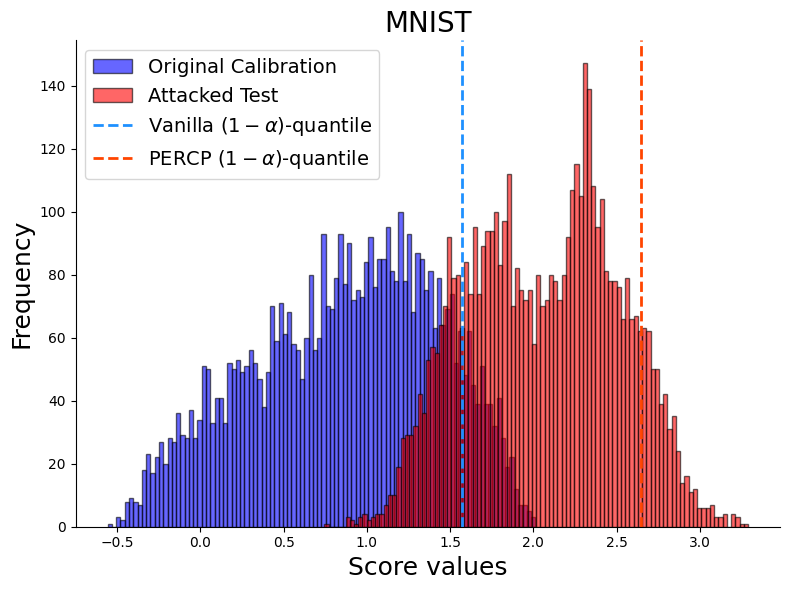

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# Plot histogram for classic calibration set
plt.hist(cl_classic_scores, bins=100, edgecolor='black', alpha=0.6,
         label='Original Calibration', color='blue')

# Plot histogram for attacked test set
plt.hist(cl_attacked_scores, bins=100, edgecolor='black', alpha=0.6,
         label='Attacked Test', color='red')

# Plot only the classic quantile
plt.axvline(x=qhat, color='dodgerblue', linestyle='dashed', linewidth=2,
            label=r'Vanilla $(1-\alpha)$-quantile')

# Plot only the classic quantile
plt.axvline(x=qhat_A, color='orangered', linestyle='dashed', linewidth=2,
            label=r'PERCP $(1-\alpha)$-quantile')

# Titles and labels with increased font sizes
plt.title('MNIST', fontsize=20)
plt.xlabel(r'Score values', fontsize=18)
plt.ylabel('Frequency', fontsize=18)

# Legend with bigger font
plt.legend(fontsize=14)

# Remove top and right spines
for spine in ['top', 'right']:
    plt.gca().spines[spine].set_visible(False)

# No grid
plt.grid(False)

# Tighter layout for Overleaf
plt.tight_layout()

# Save as a PDF
plt.savefig('score_distribution.pdf')

plt.show()


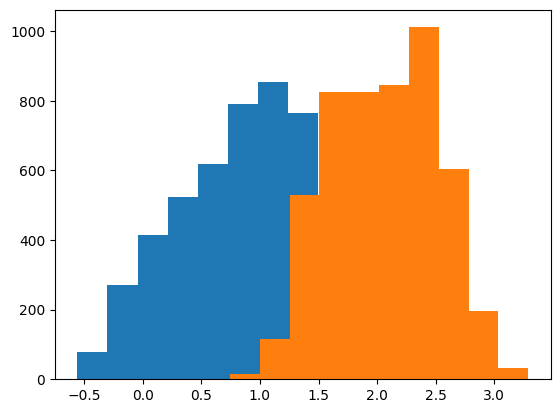

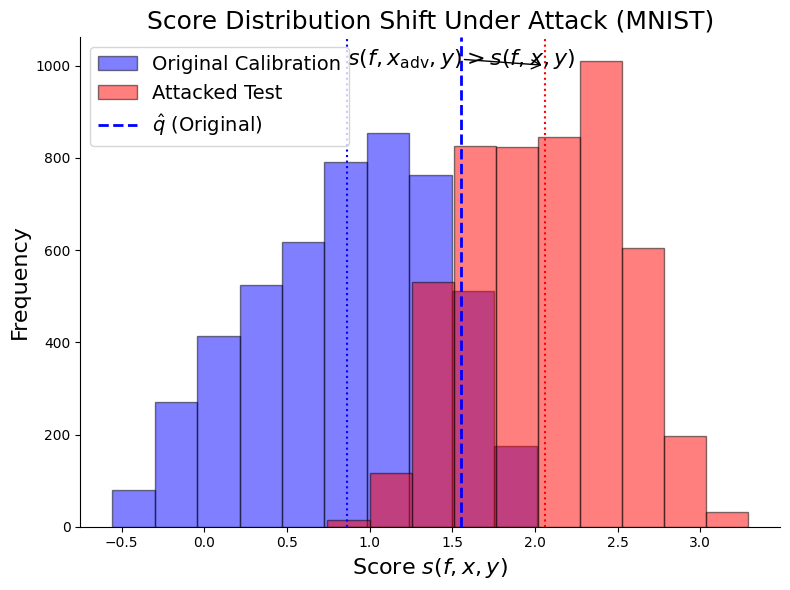

## Compute the Conformal Set

In [49]:
def compute_CP(dataset, qhat):
    
    conformal_sets = []  # List to store conformal sets for each test point

    for x in dataset:
     # Initialize the conformal set for this sample
        conformal_set = []

        # Check each class digit
        for d in digits:
            # Compute the score function for the current digit
            score = s(x, CArray([d]))

            # Add the digit to the conformal set if the score satisfies the threshold
            if score <= qhat:
                conformal_set.append(d)

        # Store the conformal set for this sample
        conformal_sets.append(conformal_set)

    return conformal_sets
    

In [50]:
def evaluate_conformal_sets(dataset, conformal_sets):
    
    # %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% COVERAGE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%% #
    true_label_in_conformal_set = []
    n = dataset.X.shape[0]  # Assuming `dataset` is a list or similar iterable
    
    for i in range(n):
        y0 = dataset[i,:].Y
        conformal_set = conformal_sets[i]
        true_label_in_conformal_set.append(y0 in conformal_set)

    n_correct = sum(true_label_in_conformal_set)
    accuracy = n_correct / n * 100
    
    print(f"True label is in the conformal set for {n_correct}/{n} test samples ({accuracy:.2f}%).")

    # %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% SETS SIZE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%% #
    conformal_set_sizes = [len(conformal_set) for conformal_set in conformal_sets]

    count_0 = conformal_set_sizes.count(0)
    count_1 = conformal_set_sizes.count(1)
    count_2 = conformal_set_sizes.count(2)
    count_3 = conformal_set_sizes.count(3)
    count_4 = conformal_set_sizes.count(4)
    count_5 = conformal_set_sizes.count(5)
    count_6 = conformal_set_sizes.count(6)
    count_7 = conformal_set_sizes.count(7)
    count_8 = conformal_set_sizes.count(8)
    count_9 = conformal_set_sizes.count(9)
    count_10 = conformal_set_sizes.count(10)
    

    print(f"Number of conformal sets with size 0: {count_0}")
    print(f"Number of conformal sets with size 1: {count_1}")
    print(f"Number of conformal sets with size 2: {count_2}")
    print(f"Number of conformal sets with size 3: {count_3}")
    print(f"Number of conformal sets with size 4: {count_4}")
    print(f"Number of conformal sets with size 5: {count_5}")
    print(f"Number of conformal sets with size 6: {count_6}")
    print(f"Number of conformal sets with size 7: {count_7}")
    print(f"Number of conformal sets with size 8: {count_8}")
    print(f"Number of conformal sets with size 9: {count_9}")
    print(f"Number of conformal sets with size 10: {count_10}")

    return accuracy, count_0, count_1, count_2, count_3, count_4, count_5, count_6, count_7, count_8, count_9, count_10


In [51]:
def calibration_curve(dataset, X_set, calibration_scores):

    scores = []
    labels = dataset.Y.tondarray()
    
    n_cl = len(calibration_scores)
    
    for x in X_set:
        scores.append([s(x, CArray([d])) for d in digits]) 

    scores = np.array(scores)  
    labels = np.array(labels)
        
    alphas = np.linspace(0.01, 0.9, 50)
    probabilities = []

    for alpha in alphas:
        q_level = np.ceil((n_cl + 1) * (1 - alpha)) / n_cl
        qhat = np.quantile(calibration_scores, q_level, method='higher')
        
        conformal_sets = scores <= qhat  

        true_label_in_conformal_set = [
            conformal_sets[i, digits.index(y)] for i, y in enumerate(labels)
        ]    
        
        n_correct = sum(true_label_in_conformal_set)
        probability = n_correct / len(X_set)
        probabilities.append(probability)

    return probabilities, alphas

In [52]:
def plot_conformal(dataset, conformal_sets, X_set, calibration_scores):
    
    conformal_set_sizes = [len(conformal_set) for conformal_set in conformal_sets]

    # Ensure we include a bin for 0 class size
    conformal_set_sizes = [0 if size == 0 else size for size in conformal_set_sizes]
    probabilities, alphas = calibration_curve(dataset, X_set, calibration_scores)
            
    # %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% PLOTTING SUBPLOTS %%%%%%%%%%%%%%%%%%%%%%%%%%%%%% #

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Plot 1: Histogram of conformal set sizes with 0 class size bin colored red
    bins = np.arange(0, max(conformal_set_sizes) + 2) - 0.5  # Add 0 bin
    axes[0].hist(conformal_set_sizes, bins=bins, edgecolor='black', rwidth=0.8, color='blue')
    
    # Color the bin for size 0 in red
    axes[0].patches[0].set_facecolor('red')
    
    axes[0].set_title("Conformal Set Sizes", fontsize=14)
    axes[0].set_xlabel("Set Size (Number of Labels in Conformal Set)", fontsize=12)
    axes[0].set_ylabel("Frequency", fontsize=12)
    axes[0].set_xticks(np.arange(0, max(conformal_set_sizes) + 2))
    
    # Plot 2: Calibration curve
    axes[1].plot(alphas, probabilities, marker='o', label='True label probability')
    axes[1].plot(alphas, 1 - alphas, color='r', linestyle='--', label='Expected coverage (1 - alpha)')
    axes[1].set_xlabel(r'$\alpha$ (Significance level)', fontsize=12)
    axes[1].set_ylabel('Probability of true label in conformal set', fontsize=12)
    axes[1].set_title('True Label Coverage vs. Alpha', fontsize=14)
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

## Compute the conformal set

# Classic

True label is in the conformal set for 1746/2000 test samples (87.30%).
Number of conformal sets with size 0: 198
Number of conformal sets with size 1: 1647
Number of conformal sets with size 2: 151
Number of conformal sets with size 3: 4
Number of conformal sets with size 4: 0
Number of conformal sets with size 5: 0
Number of conformal sets with size 6: 0
Number of conformal sets with size 7: 0
Number of conformal sets with size 8: 0
Number of conformal sets with size 9: 0
Number of conformal sets with size 10: 0


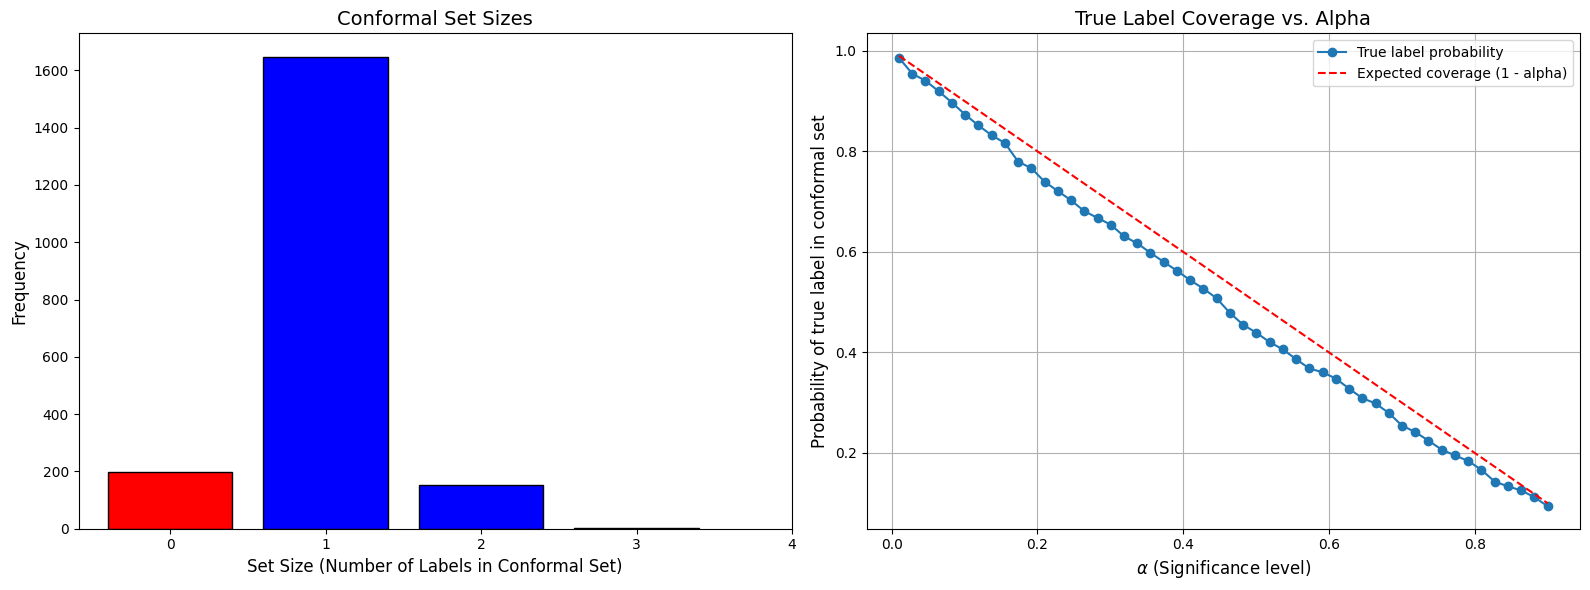

In [53]:
conformal_sets = compute_CP(test_set.X.tondarray(), qhat)
_,_,_,_,_,_,_,_,_,_,_,_ = evaluate_conformal_sets(test_set, conformal_sets)
plot_conformal(test_set, conformal_sets, test_set.X.tondarray(), cl_classic_scores)


## Attack

True label is in the conformal set for 1774/2000 test samples (88.70%).
Number of conformal sets with size 0: 0
Number of conformal sets with size 1: 8
Number of conformal sets with size 2: 51
Number of conformal sets with size 3: 128
Number of conformal sets with size 4: 267
Number of conformal sets with size 5: 323
Number of conformal sets with size 6: 350
Number of conformal sets with size 7: 268
Number of conformal sets with size 8: 476
Number of conformal sets with size 9: 129
Number of conformal sets with size 10: 0


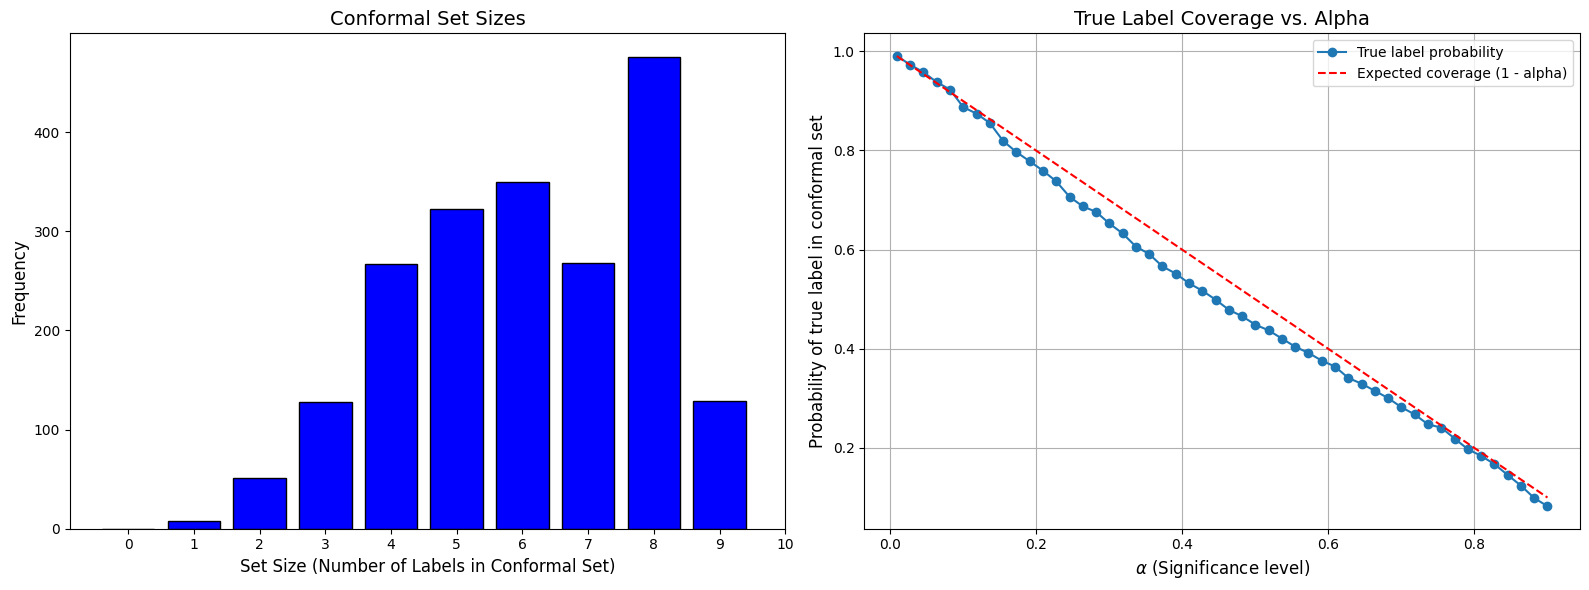

In [54]:
conformal_sets_attack = compute_CP(test_attacked, qhat_A)
_,_,_,_,_,_,_,_,_,_,_,_ = evaluate_conformal_sets(test_set, conformal_sets_attack)
plot_conformal(test_set, conformal_sets_attack, test_attacked, cl_attacked_scores)


## Attacked samples - Classic CP

True label is in the conformal set for 4/200 test samples (2.00%).
Number of conformal sets with size 0: 24
Number of conformal sets with size 1: 176
Number of conformal sets with size 2: 0
Number of conformal sets with size 3: 0
Number of conformal sets with size 4: 0
Number of conformal sets with size 5: 0
Number of conformal sets with size 6: 0
Number of conformal sets with size 7: 0
Number of conformal sets with size 8: 0
Number of conformal sets with size 9: 0
Number of conformal sets with size 10: 0


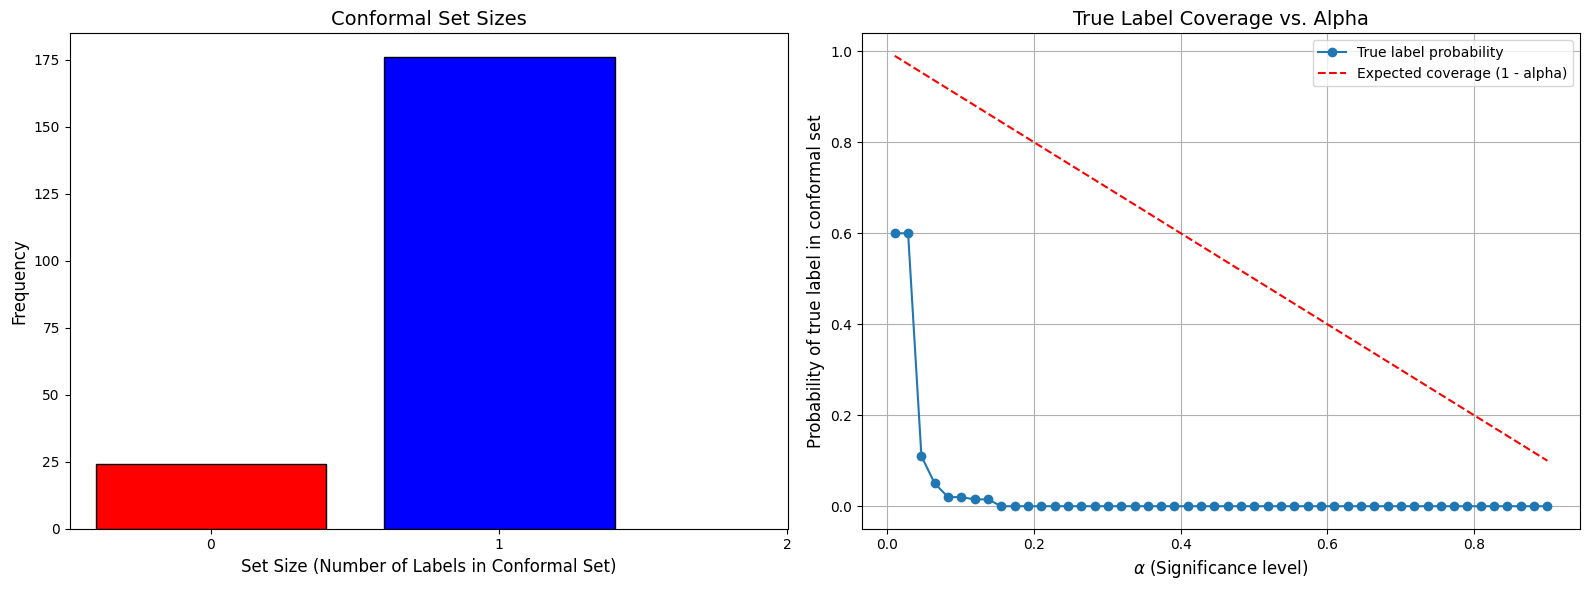

In [30]:
conformal_sets_attack_classic = compute_CP(test_attacked, qhat)
_,_,_,_,_,_,_,_,_,_,_,_ = evaluate_conformal_sets(test_set, conformal_sets_attack_classic)
plot_conformal(test_set, conformal_sets_attack_classic, test_attacked, cl_classic_scores)


## Not attacked samples - Attacked CP

True label is in the conformal set for 200/200 test samples (100.00%).
Number of conformal sets with size 0: 0
Number of conformal sets with size 1: 43
Number of conformal sets with size 2: 32
Number of conformal sets with size 3: 23
Number of conformal sets with size 4: 28
Number of conformal sets with size 5: 17
Number of conformal sets with size 6: 16
Number of conformal sets with size 7: 12
Number of conformal sets with size 8: 11
Number of conformal sets with size 9: 7
Number of conformal sets with size 10: 11


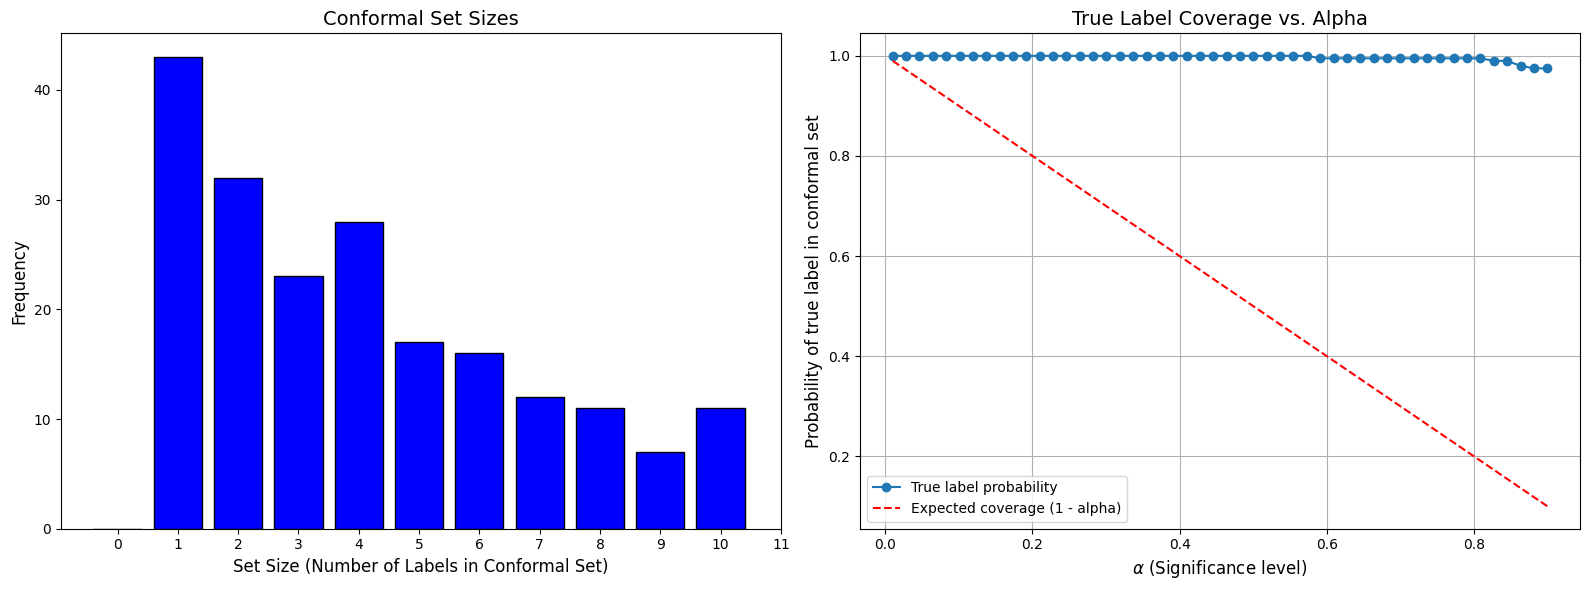

In [31]:
conformal_sets_classic_attack = compute_CP(test_set.X.tondarray(), qhat_A)
_,_,_,_,_,_,_,_,_,_,_,_ = evaluate_conformal_sets(test_set, conformal_sets_classic_attack)
plot_conformal(test_set, conformal_sets_classic_attack, test_set.X.tondarray(), cl_attacked_scores)


### Dummy plot on the calibration set

True label is in the conformal set for 92/100 test samples (92.00%).
Number of conformal sets with size 0: 6
Number of conformal sets with size 1: 94
Number of conformal sets with size 2: 0
Number of conformal sets with size 3: 0
Number of conformal sets with size 4: 0
Number of conformal sets with size 5: 0
Number of conformal sets with size 6: 0
Number of conformal sets with size 7: 0
Number of conformal sets with size 8: 0
Number of conformal sets with size 9: 0
Number of conformal sets with size 10: 0


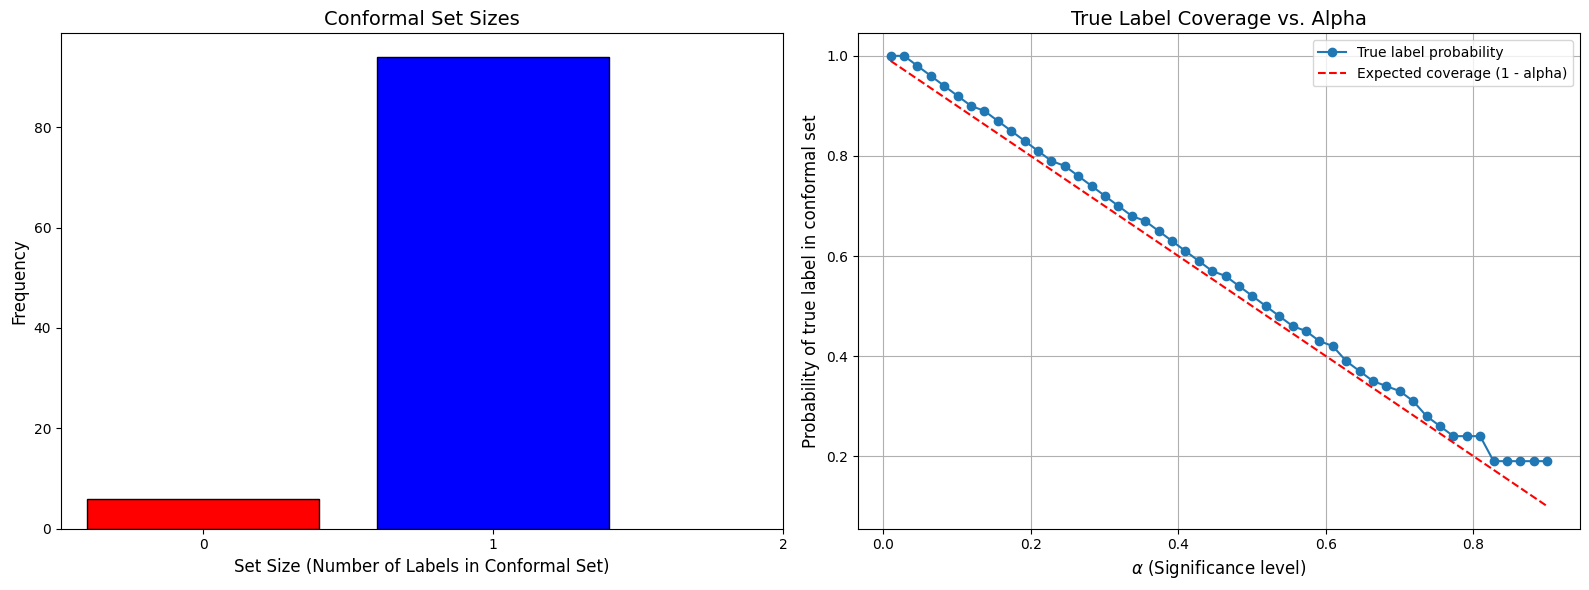

In [32]:
conformal_sets = compute_CP(calibration_set.X.tondarray(), qhat)
_,_,_,_,_,_,_,_,_,_,_,_ = evaluate_conformal_sets(calibration_set, conformal_sets)
plot_conformal(calibration_set, conformal_sets, calibration_set.X.tondarray(), cl_classic_scores)


True label is in the conformal set for 92/100 test samples (92.00%).
Number of conformal sets with size 0: 0
Number of conformal sets with size 1: 6
Number of conformal sets with size 2: 5
Number of conformal sets with size 3: 2
Number of conformal sets with size 4: 13
Number of conformal sets with size 5: 13
Number of conformal sets with size 6: 13
Number of conformal sets with size 7: 13
Number of conformal sets with size 8: 4
Number of conformal sets with size 9: 10
Number of conformal sets with size 10: 21


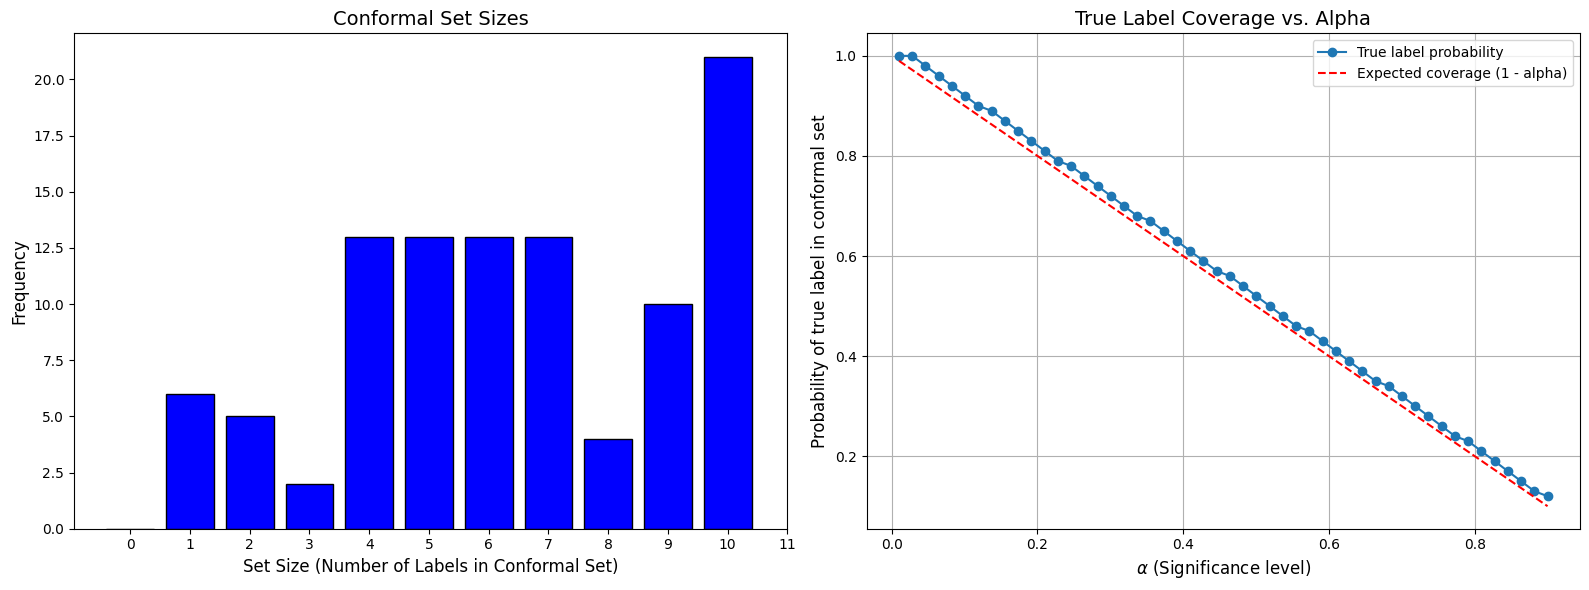

In [33]:
conformal_sets_2 = compute_CP(calibration_attacked, qhat_A)
_,_,_,_,_,_,_,_,_,_,_,_ = evaluate_conformal_sets(calibration_set, conformal_sets_2)
plot_conformal(calibration_set, conformal_sets_2, calibration_attacked, cl_attacked_scores)


## Other plots

In [55]:
test_scores = []

for x_adv in test_attacked:
    test_scores.append([s(x_adv, CArray([d])) for d in digits]) 
    
test_scores = np.array(test_scores)  

Attacking with epsilon=4.591836734693878: 100%|██████████| 50/50 [00:04<00:00, 11.93sample/s]


Size as epsilon varies: 100%|██████████| 50/50 [09:21<00:00, 11.22s/it]


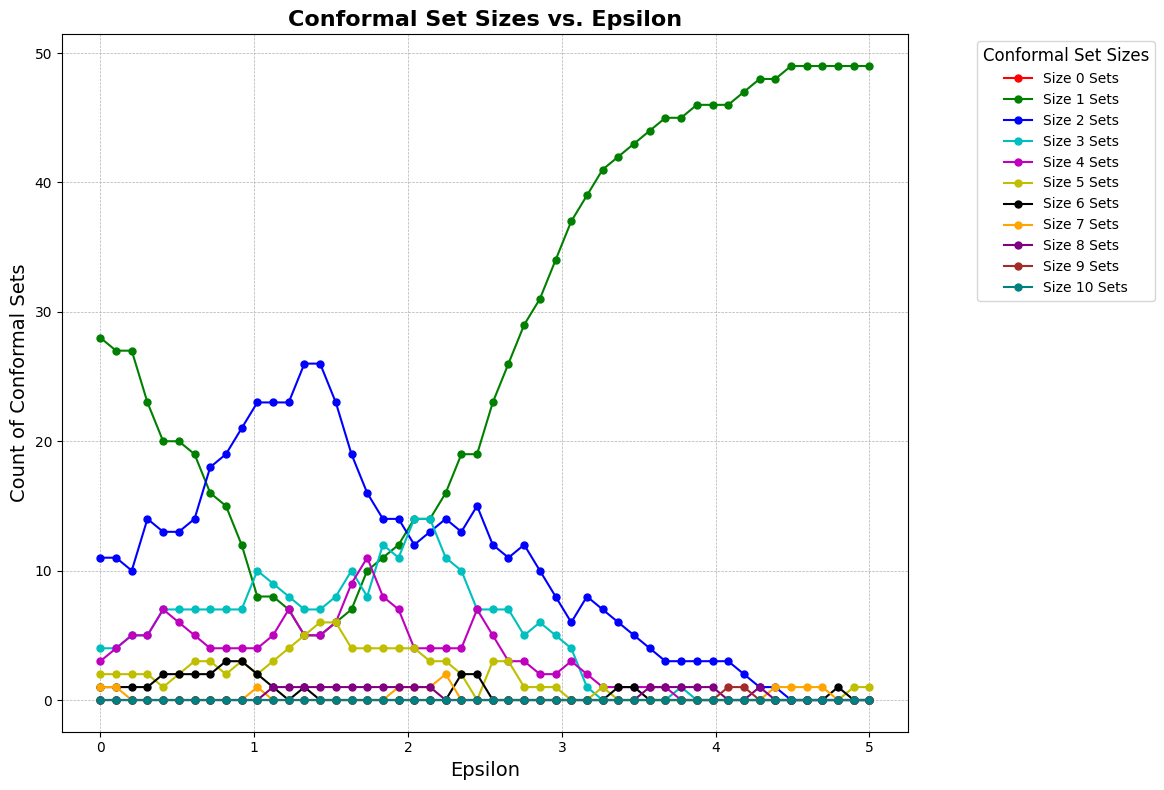

In [81]:
# Error of the classifier
test_subset = test_set[:50,:]

# Epsilon values
Epsilon = np.linspace(0, 5, 50)  # Generate 50 values between 0.01 and 1

conformal_set_sizes_0 = []  # To store counts of size 0 conformal sets
conformal_set_sizes_1 = []  # To store counts of size 1 conformal sets
conformal_set_sizes_2 = []  # To store counts of size 2 conformal sets
conformal_set_sizes_3 = []
conformal_set_sizes_4 = []
conformal_set_sizes_5 = []
conformal_set_sizes_6 = []
conformal_set_sizes_7 = []
conformal_set_sizes_8 = []
conformal_set_sizes_9 = []
conformal_set_sizes_10 = []

q_level = np.ceil((n_cl + 1) * (1 - alpha)) / n_cl

# Iterate over each epsilon value
for eps in tqdm(Epsilon, desc="Size as epsilon varies"):
    # Perform the attack on the test set
    attacked_test = attack_dataset(test_subset, f"Attacking with epsilon={eps}", clf, epsilon=eps)
    attacked_test_array = np.vstack([sample.tondarray() for sample in attacked_test])
    attacked_test = CArray(attacked_test_array)
    
    ts_attacked_scores_eps = []
        
    for i in range(50):
        
        x_adv =  attacked_test[i,:]
        
        ts_attacked_scores_eps.append([s(x_adv, CArray([d])) for d in digits])
    
    # Quantile of the attacked scores
    qhat_A = np.quantile(cl_attacked_scores, q_level, method='higher')
    
    # Compute conformal prediction sets
    conformal_sets = ts_attacked_scores_eps <= qhat_A 
            
    # Record the sizes of the conformal sets
    conformal_set_sizes = np.sum(conformal_sets, axis=1).tolist()
                
    # Count the number of sets of size 0, 1, and 2
    count_0 = conformal_set_sizes.count(0)
    count_1 = conformal_set_sizes.count(1)
    count_2 = conformal_set_sizes.count(2)
    count_3 = conformal_set_sizes.count(3)
    count_4 = conformal_set_sizes.count(4)
    count_5 = conformal_set_sizes.count(5)
    count_6 = conformal_set_sizes.count(6)
    count_7 = conformal_set_sizes.count(7)
    count_8 = conformal_set_sizes.count(8)
    count_9 = conformal_set_sizes.count(9)
    count_10 = conformal_set_sizes.count(10)
    
    # Append the counts to the corresponding lists
    conformal_set_sizes_0.append(count_0)
    conformal_set_sizes_1.append(count_1)
    conformal_set_sizes_2.append(count_2)
    conformal_set_sizes_3.append(count_3)
    conformal_set_sizes_4.append(count_4)                                     
    conformal_set_sizes_5.append(count_5)
    conformal_set_sizes_6.append(count_6) 
    conformal_set_sizes_7.append(count_7)                                     
    conformal_set_sizes_8.append(count_8)                                     
    conformal_set_sizes_9.append(count_9)
    conformal_set_sizes_10.append(count_10)                                     
                                         
# Define the list of colors for the plot
colors = ['r', 'g', 'b', 'c', 'm', 'y', 'k', '#FFA500', '#800080', '#A52A2A', '#008080']

# Create the plot
plt.figure(figsize=(12, 8))

# Define labels for the conformal set sizes
labels = [f"Size {i} Sets" for i in range(11)]

# Plot each conformal set size count as a separate curve
for i, (conformal_size, color, label) in enumerate(zip(
        [conformal_set_sizes_0, conformal_set_sizes_1, conformal_set_sizes_2,
         conformal_set_sizes_3, conformal_set_sizes_4, conformal_set_sizes_5,
         conformal_set_sizes_6, conformal_set_sizes_7, conformal_set_sizes_8,
         conformal_set_sizes_9, conformal_set_sizes_10],
        colors, labels)):
    plt.plot(Epsilon, conformal_size, marker='o', label=label, color=color, markersize=5, linewidth=1.5)

# Customize plot appearance
plt.xlabel("Epsilon", fontsize=14)
plt.ylabel("Count of Conformal Sets", fontsize=14)
plt.title("Conformal Set Sizes vs. Epsilon", fontsize=16, fontweight='bold')
plt.legend(title="Conformal Set Sizes", title_fontsize=12, fontsize=10, loc='upper right', bbox_to_anchor=(1.3, 1))
plt.grid(visible=True, linestyle='--', linewidth=0.5)
plt.tight_layout()

# Show the plot
plt.show()

In [80]:
for i, (conformal_size, color, label) in enumerate(zip(
        [conformal_set_sizes_0, conformal_set_sizes_1, conformal_set_sizes_2,
         conformal_set_sizes_3, conformal_set_sizes_4, conformal_set_sizes_5,
         conformal_set_sizes_6, conformal_set_sizes_7, conformal_set_sizes_8,
         conformal_set_sizes_9, conformal_set_sizes_10],
        colors, labels)):
    print(conformal_size[0])

0
28
11
4
3
2
1
1
0
0
0


Processing: 100%|██████████| 50/50 [00:00<00:00, 1578.31sample/s]


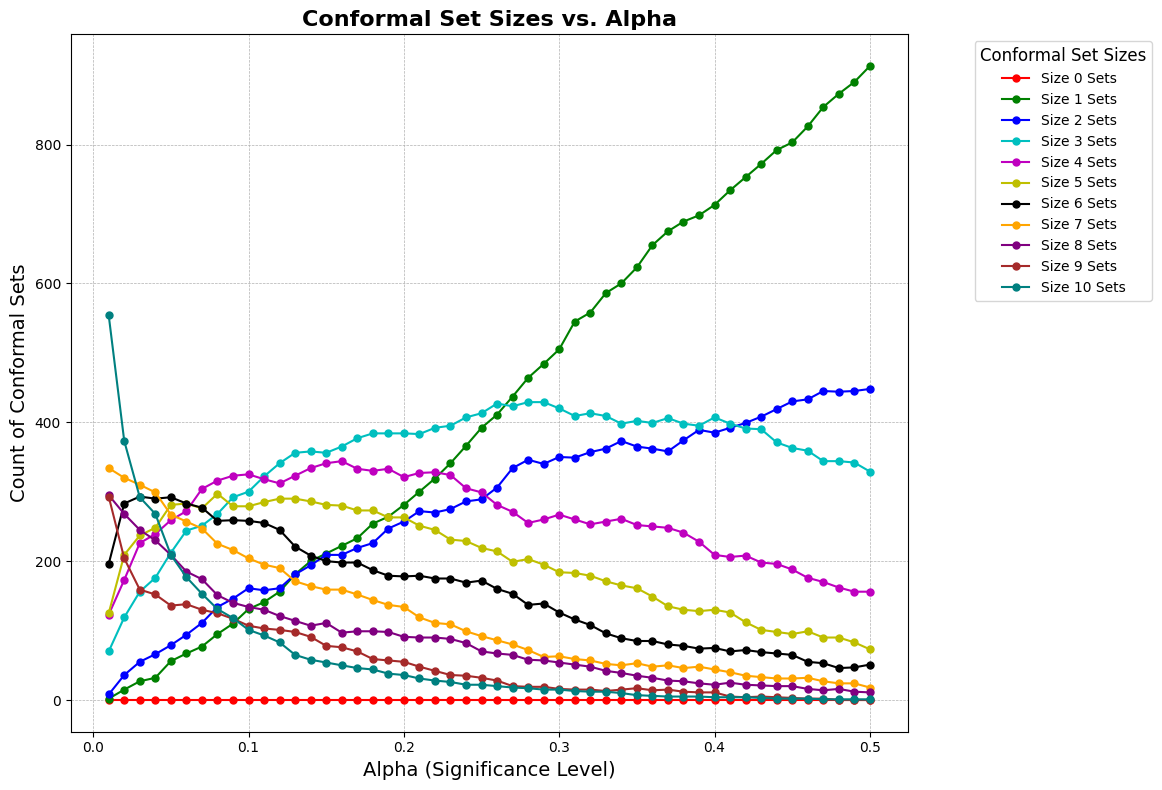

In [44]:
# Parameters
alpha_values = np.linspace(0.01, 0.5, 50)  # Range of alpha values to evaluate
conformal_set_sizes_0 = []  # To store counts of size 0 conformal sets
conformal_set_sizes_1 = []  # To store counts of size 1 conformal sets
conformal_set_sizes_2 = []  # To store counts of size 2 conformal sets
conformal_set_sizes_3 = []
conformal_set_sizes_4 = []
conformal_set_sizes_5 = []
conformal_set_sizes_6 = []
conformal_set_sizes_7 = []
conformal_set_sizes_8 = []
conformal_set_sizes_9 = []
conformal_set_sizes_10 = []

# Loop over alpha values with a progress bar
for alpha in tqdm(alpha_values, desc='Processing', unit='sample'):
    # Compute the quantile level for the current alpha
    q_level = np.ceil((n_cl + 1) * (1 - alpha)) / n_cl
    
    # Quantile of the attacked scores
    qhat_A = np.quantile(cl_attacked_scores, q_level, method='higher')
    
    # Compute conformal prediction sets
    conformal_sets = test_scores <= qhat_A    
        
    # Record the sizes of the conformal sets
    conformal_set_sizes = np.sum(conformal_sets, axis=1).tolist()
        
    # Count the number of sets of size 0, 1, and 2
    count_0 = conformal_set_sizes.count(0)
    count_1 = conformal_set_sizes.count(1)
    count_2 = conformal_set_sizes.count(2)
    count_3 = conformal_set_sizes.count(3)
    count_4 = conformal_set_sizes.count(4)
    count_5 = conformal_set_sizes.count(5)
    count_6 = conformal_set_sizes.count(6)
    count_7 = conformal_set_sizes.count(7)
    count_8 = conformal_set_sizes.count(8)
    count_9 = conformal_set_sizes.count(9)
    count_10 = conformal_set_sizes.count(10)
    
    # Append the counts to the corresponding lists
    conformal_set_sizes_0.append(count_0)
    conformal_set_sizes_1.append(count_1)
    conformal_set_sizes_2.append(count_2)
    conformal_set_sizes_3.append(count_3)
    conformal_set_sizes_4.append(count_4)                                     
    conformal_set_sizes_5.append(count_5)
    conformal_set_sizes_6.append(count_6) 
    conformal_set_sizes_7.append(count_7)                                     
    conformal_set_sizes_8.append(count_8)                                     
    conformal_set_sizes_9.append(count_9)
    conformal_set_sizes_10.append(count_10)                                     
                                         
# Define the list of colors for the plot
colors = ['r', 'g', 'b', 'c', 'm', 'y', 'k', '#FFA500', '#800080', '#A52A2A', '#008080']

# Create the plot
plt.figure(figsize=(12, 8))

# Define labels for the conformal set sizes
labels = [f"Size {i} Sets" for i in range(11)]

# Plot each conformal set size count as a separate curve
for i, (conformal_size, color, label) in enumerate(zip(
        [conformal_set_sizes_0, conformal_set_sizes_1, conformal_set_sizes_2,
         conformal_set_sizes_3, conformal_set_sizes_4, conformal_set_sizes_5,
         conformal_set_sizes_6, conformal_set_sizes_7, conformal_set_sizes_8,
         conformal_set_sizes_9, conformal_set_sizes_10],
        colors, labels)):
    plt.plot(alpha_values, conformal_size, marker='o', label=label, color=color, markersize=5, linewidth=1.5)

# Customize plot appearance
plt.xlabel("Alpha (Significance Level)", fontsize=14)
plt.ylabel("Count of Conformal Sets", fontsize=14)
plt.title("Conformal Set Sizes vs. Alpha", fontsize=16, fontweight='bold')
plt.legend(title="Conformal Set Sizes", title_fontsize=12, fontsize=10, loc='upper right', bbox_to_anchor=(1.3, 1))
plt.grid(visible=True, linestyle='--', linewidth=0.5)
plt.tight_layout()

# Show the plot
plt.show()


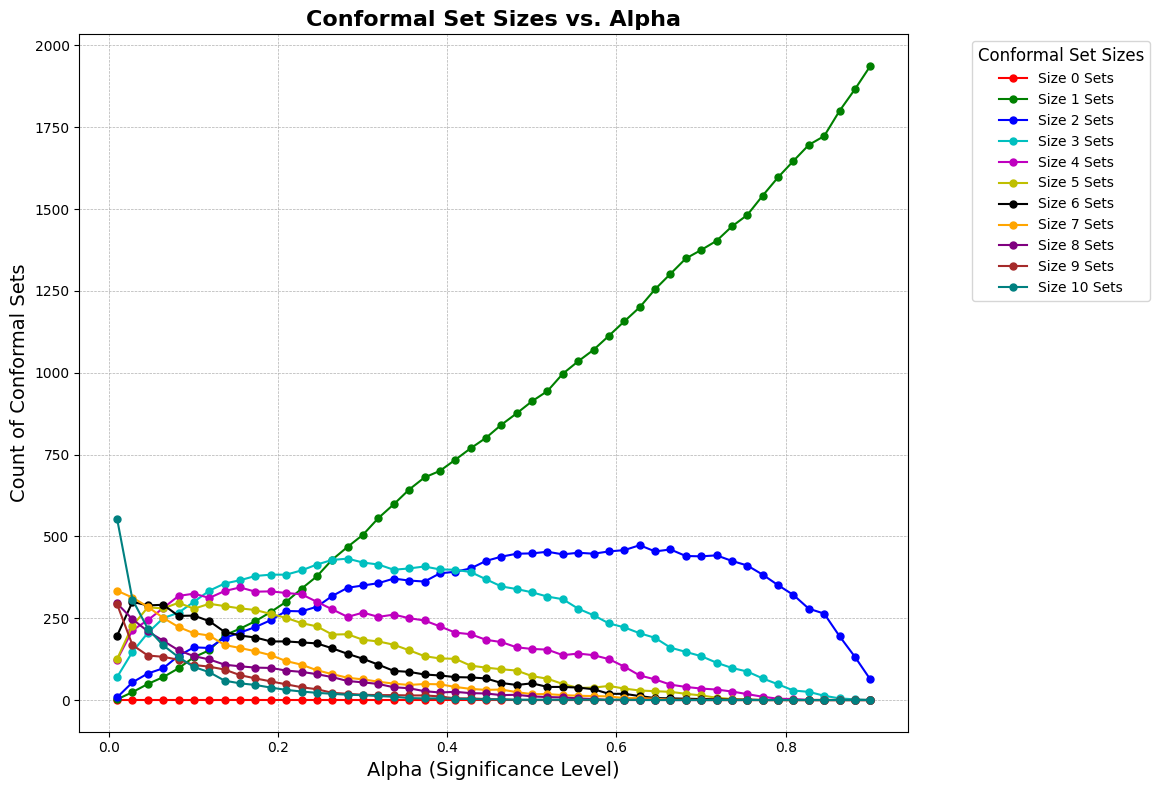